# OneStop English — aligned triples only

This notebook uses the **official** [OneStopEnglishCorpus](https://github.com/nishkalavallabhi/OneStopEnglishCorpus) release: folder **`Texts-Together-OneCSVperFile`** (or the repo root). Each CSV is **one article** with three **paragraph-aligned** columns (Elementary, Intermediate, Advanced). There are **189 articles**, each appearing **exactly once per level** — no Hugging Face shuffle and no heuristic matching.

By default **`OSE_CORPUS_ROOT`** points at `data/OneStopEnglishCorpus` inside this project (clone the GitHub repo there if needed), then run all cells.

In [1]:
from __future__ import annotations

import importlib.util
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "setup_onestop_english.py").is_file():
        return cwd
    nested = cwd / "LGP-score"
    if (nested / "setup_onestop_english.py").is_file():
        return nested
    raise FileNotFoundError(
        "Set the notebook working directory to the LGP-score folder "
        "(where setup_onestop_english.py lives), then rerun this cell."
    )


_setup_path = _project_root() / "setup_onestop_english.py"
# Drop any cached import so we always load the current file from disk.
sys.modules.pop("setup_onestop_english", None)
_spec = importlib.util.spec_from_file_location("setup_onestop_english", _setup_path)
if _spec is None or _spec.loader is None:
    raise ImportError(f"Could not load {_setup_path}")
_mod = importlib.util.module_from_spec(_spec)
sys.modules["setup_onestop_english"] = _mod
_spec.loader.exec_module(_mod)

LEVEL_ID_TO_TEXT = _mod.LEVEL_ID_TO_TEXT
load_onestop_english_aligned = getattr(_mod, "load_onestop_english_aligned", None)
if load_onestop_english_aligned is None:
    raise ImportError(
        f"{_setup_path} has no load_onestop_english_aligned — save the latest "
        "version from the repo (or git pull) and rerun this cell."
    )

sns.set_theme(context="notebook", style="whitegrid")
%matplotlib inline

LEVEL_ORDER = ["Elementary", "Intermediate", "Advance"]

In [2]:
# Default: corpus under this repo (clone if missing):
#   git clone https://github.com/nishkalavallabhi/OneStopEnglishCorpus.git data/OneStopEnglishCorpus
# Or set OSE_CORPUS_ROOT to any folder that is (or contains) Texts-Together-OneCSVperFile.
OSE_CORPUS_ROOT = _project_root() / "data" / "OneStopEnglishCorpus"

if not OSE_CORPUS_ROOT.is_dir():
    raise FileNotFoundError(
        f"OSE_CORPUS_ROOT is not an existing folder: {OSE_CORPUS_ROOT}\n"
        "Clone https://github.com/nishkalavallabhi/OneStopEnglishCorpus into data/OneStopEnglishCorpus "
        "or change OSE_CORPUS_ROOT to your local path."
    )

ose_df = load_onestop_english_aligned(OSE_CORPUS_ROOT)

n_stories = ose_df["story_id"].nunique()
assert len(ose_df) == 3 * n_stories, "Every story should have exactly three rows"
assert set(ose_df["level_id"].unique()) == {0, 1, 2}
assert n_stories == 189, f"Expected 189 CSVs, got {n_stories}"

ose_df.head(6)

,text,level,level_id,split,story_id
0,"When you see the word Amazon, what’s\nthe firs...",Elementary,0,aligned,Amazon
1,"When you see the word Amazon, what’s\nthe firs...",Intermediate,1,aligned,Amazon
2,"When you see the word Amazon, what’s the\nfirs...",Advance,2,aligned,Amazon
3,"To tourists, Amsterdam still seems very libera...",Elementary,0,aligned,Amsterdam
4,"To tourists, Amsterdam still seems very libera...",Intermediate,1,aligned,Amsterdam
5,"Amsterdam still looks liberal to tourists, who...",Advance,2,aligned,Amsterdam


In [3]:
# One row per article; columns are the three levels (same story, three simplifications)
articles = ose_df.pivot_table(
    index="story_id", columns="level", values="text", aggfunc="first"
)[LEVEL_ORDER]

for lvl in LEVEL_ORDER:
    articles[f"word_count_{lvl}"] = articles[lvl].str.split().str.len()
    articles[f"char_len_{lvl}"] = articles[lvl].str.len()

articles["word_count_mean"] = articles[[f"word_count_{l}" for l in LEVEL_ORDER]].mean(axis=1)

print(f"Articles: {len(articles)}  |  Long rows: {len(ose_df)}")
articles.head(3)

Articles: 189  |  Long rows: 567


level,Elementary,Intermediate,Advance,word_count_Elementary,char_len_Elementary,word_count_Intermediate,char_len_Intermediate,word_count_Advance,char_len_Advance,word_count_mean
story_id,,,,,,,,,,
Amazon,"When you see the word Amazon, what’s\nthe firs...","When you see the word Amazon, what’s\nthe firs...","When you see the word Amazon, what’s the\nfirs...",419,2560,518,3187,622,3884,519.666667
Amsterdam,"To tourists, Amsterdam still seems very libera...","To tourists, Amsterdam still seems very libera...","Amsterdam still looks liberal to tourists, who...",446,2573,452,2722,452,2750,450.000000
Anita,"Anitta, a music star from Brazil, has millions...","Brazil’s latest funk sensation, Anitta, has wo...","Brazil’s latest funk sensation, Anitta, has wo...",462,2559,693,4017,937,5517,697.333333


In [4]:
# Long-form metrics for plots (each row still tied to story_id)
ose_df = ose_df.copy()
ose_df["char_len"] = ose_df["text"].str.len()
ose_df["word_count"] = ose_df["text"].str.split().str.len()

ose_df[["char_len", "word_count"]].describe()

,char_len,word_count
count,567.000000,567.000000
mean,3974.088183,680.388007
std,1052.436135,176.420528
min,1452.000000,260.000000
25%,3259.500000,564.500000
50%,3873.000000,665.000000
75%,4589.500000,784.500000
max,7961.000000,1379.000000


In [5]:
print("Rows per level (should be 189 each):")
display(ose_df["level"].value_counts().reindex(LEVEL_ORDER))
print("All rows are split='aligned':", (ose_df["split"] == "aligned").all())

Rows per level (should be 189 each):


level
Elementary      189
Intermediate    189
Advance         189
Name: count, dtype: int64

All rows are split='aligned': True


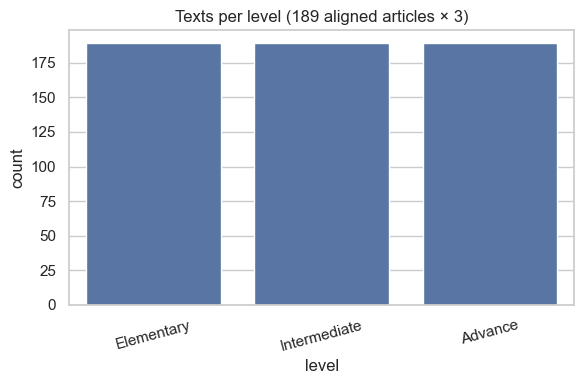

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=ose_df, x="level", order=LEVEL_ORDER, ax=ax)
ax.set_title("Texts per level (189 aligned articles × 3)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()

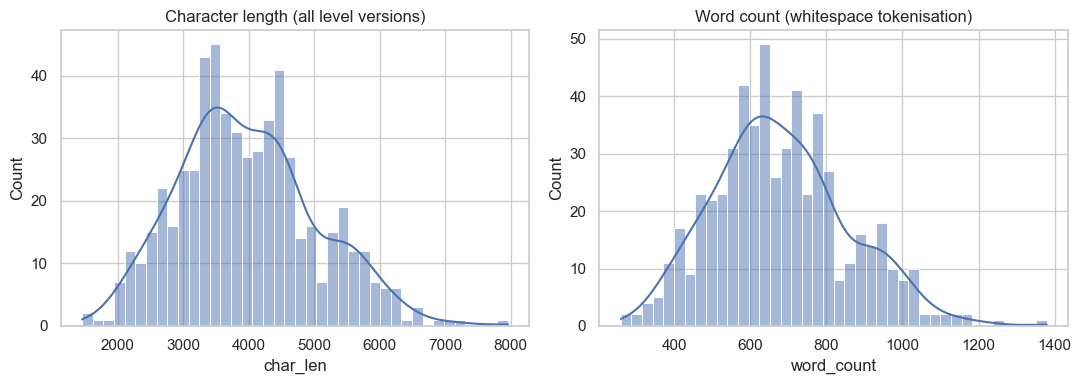

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(ose_df["char_len"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Character length (all level versions)")
sns.histplot(ose_df["word_count"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Word count (whitespace tokenisation)")
plt.tight_layout()

char_len                      word_count                   
                     mean  median         std        mean median         std
level                                                                       
Elementary    3061.396825  3124.0  578.986198  535.825397  546.0  104.343674
Intermediate  3976.063492  4083.0  664.528233  680.095238  693.0  117.927499
Advance       4884.804233  4878.0  941.578523  825.243386  809.0  163.722112

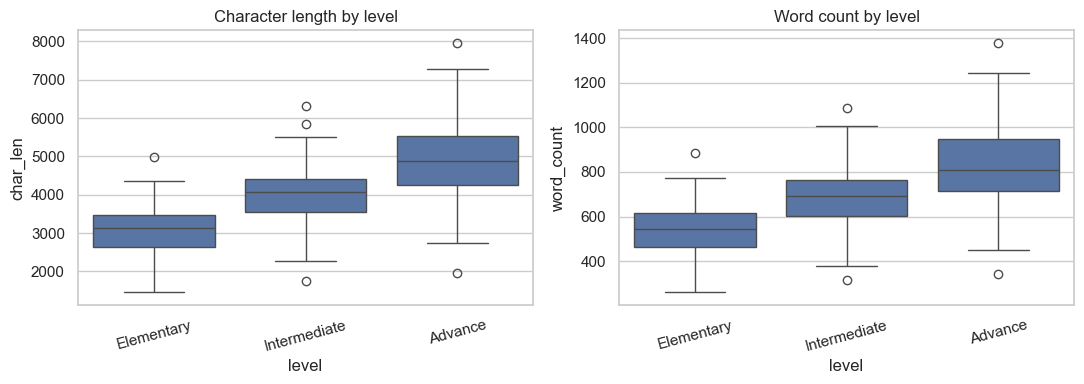

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=ose_df, x="level", y="char_len", order=LEVEL_ORDER, ax=axes[0])
axes[0].set_title("Character length by level")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(data=ose_df, x="level", y="word_count", order=LEVEL_ORDER, ax=axes[1])
axes[1].set_title("Word count by level")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()

ose_df.groupby("level", observed=True)[["char_len", "word_count"]].agg(
    ["mean", "median", "std"]
).reindex(LEVEL_ORDER)

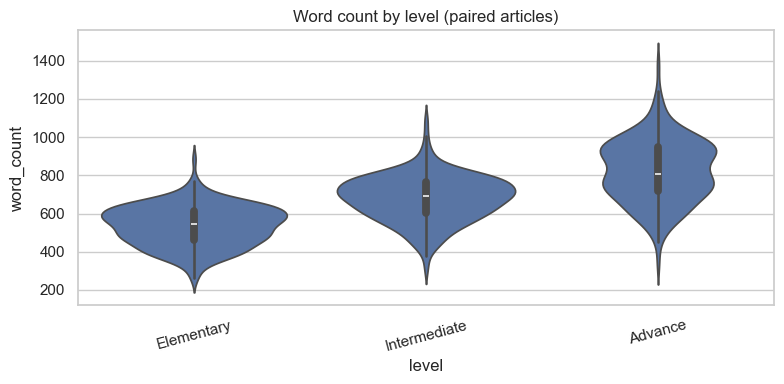

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=ose_df, x="level", y="word_count", order=LEVEL_ORDER, inner="box", ax=ax
)
ax.set_title("Word count by level (paired articles)")
plt.xticks(rotation=15)
plt.tight_layout()

Articles with Elem < Inter < Adv (word count): 187 / 189


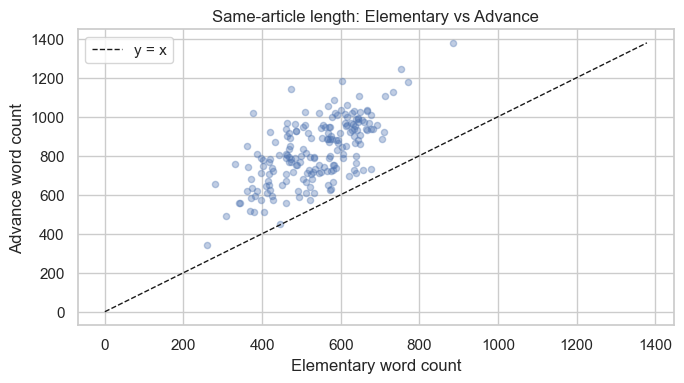

In [10]:
# Typical pattern: Elementary < Intermediate < Advance (same article)
elem = articles["word_count_Elementary"]
inter = articles["word_count_Intermediate"]
adv = articles["word_count_Advance"]
strict = ((elem < inter) & (inter < adv)).sum()
print(f"Articles with Elem < Inter < Adv (word count): {strict} / {len(articles)}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(elem, adv, alpha=0.35, s=20)
mx = max(elem.max(), adv.max())
ax.plot([0, mx], [0, mx], "k--", lw=1, label="y = x")
ax.set_xlabel("Elementary word count")
ax.set_ylabel("Advance word count")
ax.set_title("Same-article length: Elementary vs Advance")
ax.legend()
plt.tight_layout()

In [11]:
# Shortest / longest by mean word count across the three levels — full triples
short_sid = articles["word_count_mean"].idxmin()
long_sid = articles["word_count_mean"].idxmax()

for label, sid in [("Shortest (mean words)", short_sid), ("Longest (mean words)", long_sid)]:
    print("=" * 60, label, sid, sep="\n")
    row = articles.loc[sid]
    for lvl in LEVEL_ORDER:
        wc = row[f"word_count_{lvl}"]
        print(f"\n--- {lvl} ({wc} words) ---")
        t = row[lvl]
        print(t[:1200] + ("..." if len(t) > 1200 else ""))

Shortest (mean words)
WNL Lego movie

--- Elementary (260 words) ---
Lego’s profits rose strongly in the first half of
2014, helped by the success of its Lego Movie in
the US and UK.

The Danish toy company sold a lot more products
in Europe, North and South America, and Asia
as children bought products linked to the film.
The film took more than $250 million in the US
and £31 million in the UK between February and
April 2014.

The movie cost about $60 million to make. It is
entertaining and aimed at people who are likely to
buy the company’s products.

Lego’s finance director, John Goodwin, said that
the Lego Movie products had a positive effect on
profits during the first half of 2014. They are now
waiting to see what will happen after the movie
comes out on DVD in the second half of 2014.

Jørgen Vig Knudstorp, Lego’s chief executive,
said that Lego were very happy that they have
sold more products in the first half of 2014. He
said this was a result of Lego’s ability to develop,
la

In [12]:
# Random article: all three levels guaranteed to match
chosen = random.choice(articles.index.tolist())
row = articles.loc[chosen]
print(f"story_id = {chosen!r}\n")
for lvl in LEVEL_ORDER:
    wc = int(row[f"word_count_{lvl}"])
    print("=" * 60)
    print(f"Level: {lvl}  |  words: {wc}")
    print("-" * 60)
    t = row[lvl]
    print(t[:1500] + ("..." if len(t) > 1500 else ""))

story_id = 'Bolivia'

Level: Elementary  |  words: 591
------------------------------------------------------------
A big international disagreement has 1 started over the right of Bolivia’s indigenous Indian tribes to chew coca leaves, the main ingredient in cocaine. This could have a significant effect on global drugs policy. Bolivia has received a special exemption from the 1961 Convention on Drugs, the agreement that controls international drugs policy. The exemption allows Bolivia’s indigenous people to chew the leaves.

Bolivia said that the convention was against 2 its new constitution, which says it must “protect native and ancestral coca” as part of its cultural heritage and says that coca “in its natural state … is not a dangerous drug”.

South American Indians have chewed coca 3 leaves for hundreds of years. The leaves give energy and have medicinal qualities. People who support Bolivia’s position said that defending the rights of indigenous people was the right thing to do.

## Notes

- **Level IDs:** `0` = Elementary, `1` = Intermediate, `2` = Advance (`LEVEL_ID_TO_TEXT` in `setup_onestop_english.py`). The GitHub CSV column "Advanced" is stored as **Advance** for consistency with the rest of this project.
- **Word counts** use simple whitespace splitting, not linguistic tokenisation.
- For LLM batches, use `python run_onestop_english.py batch --aligned-corpus ...` so outputs stay tied to `story_id`.